# Graph Neural Network for US Corporate Bond Pricing

### A Prototype Quantitative Finance Model

**Author:** Prototype / Research Notebook  
**Date:** March 2026  
**Purpose:** Demonstrate a GNN-based spread-to-benchmark pricing model for US investment-grade and high-yield corporate bonds.

---

This notebook implements a complete pipeline:
1. **Synthetic data generation** — realistic corporate bond trading history
2. **Graph construction** — bonds as nodes, similarity-based edges
3. **GNN model** — message-passing neural network (from scratch, NumPy/SciPy)
4. **Training & validation** — with full diagnostic statistics
5. **Discussion** — assumptions, strengths, weaknesses, future research


## 0. Model Assumptions, Strengths, Weaknesses & Future Research

### 0.1 Core Assumptions

| # | Assumption | Implication |
|---|-----------|-------------|
| 1 | **Bond similarity drives spread co-movement** | Bonds with similar rating, sector, duration, and issuer trade at correlated spreads — justifying graph edges. |
| 2 | **Spread is a stationary signal given bond features** | The model predicts *current* spread level, not the full term-structure or path dependency. |
| 3 | **Time is encoded as a feature, not a recurrence** | Irregular timestamps are handled by including elapsed time since last trade and macro-regime features, not RNN layers. |
| 4 | **Graph is static within a training batch** | The bond universe is fixed per batch; the graph topology does not change mid-forward-pass. |
| 5 | **Synthetic data captures real distributional properties** | Spreads follow sector-/rating-stratified log-normal distributions with mean-reversion and macro-shock overlays. |
| 6 | **Edges are undirected and weighted by feature cosine similarity** | No directed information flow (e.g., no issuer-parent → subsidiary asymmetry in this prototype). |
| 7 | **Node features are fully observed at inference time** | No partial-observation or missing-data imputation at test time. |

### 0.2 Strengths

- **Relational inductive bias**: GNNs naturally encode the intuition that similar bonds should trade at similar spreads.
- **Cross-sectional learning**: A single model prices the entire universe simultaneously, exploiting cross-bond information.
- **Handles irregular timestamps**: Time-gap encoding avoids the need for a fixed trading grid.
- **Interpretable graph structure**: Edge weights expose which bonds most influence a given bond's predicted spread.
- **Scalable to large universes**: Graph sparsity (k-NN edges) keeps computation sub-quadratic.
- **Macro-aware**: Including macro regime features (e.g., VIX proxy, rate level) allows the model to adapt to market regimes.

### 0.3 Weaknesses & Limitations

- **Static graph topology**: In practice, bond similarity evolves as ratings change, maturities roll down, and issuers merge.
- **No temporal dynamics**: The model is a snapshot pricer; it does not model spread dynamics or momentum.
- **OTC market sparsity**: Many bonds trade infrequently. Stale node features (old trade timestamps) can degrade performance.
- **Synthetic training data**: Real spread distributions are fat-tailed, jump-diffusive, and exhibit liquidity clustering not fully captured here.
- **Cold-start problem**: Newly issued bonds have no trading history; the graph-based approach must rely entirely on static features.
- **Graph over-smoothing**: Deep GNNs can homogenize node embeddings, reducing discriminative power for isolated bonds.
- **No uncertainty quantification**: Point estimates only; no predictive intervals (Bayesian GNNs or conformal prediction needed).
- **Liquidity not modelled**: Bid-ask spread, issue size, and on-the-run/off-the-run effects are simplified.

### 0.4 Suggestions for Future Research

1. **Temporal GNN (T-GNN / EvolveGCN)**: Model the graph as time-evolving, with edge weights updated each trading day.
2. **Heterogeneous graphs**: Add issuer nodes, sector nodes, and rating-agency nodes as distinct node types with typed edges (HeteroGNN).
3. **Attention mechanisms (GAT)**: Replace fixed edge weights with learned attention to let the model discover which neighbors matter most.
4. **Inductive learning**: Use GraphSAGE-style neighborhood sampling to price bonds not seen during training (critical for new issuance).
5. **Uncertainty quantification**: Monte Carlo dropout or deep ensembles to produce spread confidence intervals.
6. **Multi-task learning**: Jointly predict spread, duration, and probability-of-downgrade in a shared GNN backbone.
7. **Alternative data integration**: News sentiment, ESG scores, and earnings surprise as additional node features.
8. **Physics-informed constraints**: Enforce no-arbitrage constraints between bonds of the same issuer in the loss function.
9. **Graph structure learning**: Jointly learn the adjacency matrix as part of model training (LDS, IDGL frameworks).
10. **Liquidity-adjusted loss**: Weight training samples by inverse bid-ask spread to prioritize liquid bond pricing accuracy.


## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import networkx as nx
import warnings
import random
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
sns.set_palette("husl")

print("✅  All libraries loaded successfully.")
print(f"   NumPy  {np.__version__}  |  Pandas  {pd.__version__}  |  NetworkX  {nx.__version__}")


✅  All libraries loaded successfully.
   NumPy  2.2.6  |  Pandas  2.3.3  |  NetworkX  3.6.1


## 2. Synthetic Dataset Generation

Generating a realistic corporate bond universe with trading history.
Each bond has static characteristics and a time series of trade records.

**Bond characteristics modelled:**
- CUSIP identifier
- Issuer (from a pool of realistic corporate names)
- Sector (GICS-aligned)
- Rating (IG: AAA → BBB-; HY: BB+ → CCC)
- Coupon (%)
- Years to maturity
- Issue size (USD millions)
- Seniority (Senior Secured / Senior Unsecured / Subordinated)
- Currency (all USD for this prototype)
- Duration (computed from coupon + maturity)
- Convexity proxy
- Callable flag
- ESG score proxy (0–100)


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.1  Bond Universe Definition
# ─────────────────────────────────────────────────────────────────────────────

SECTORS = [
    'Technology', 'Financials', 'Healthcare', 'Energy',
    'Industrials', 'Consumer Discretionary', 'Utilities',
    'Real Estate', 'Materials', 'Communication Services'
]

RATINGS_IG = ['AAA', 'AA+', 'AA', 'AA-', 'A+', 'A', 'A-', 'BBB+', 'BBB', 'BBB-']
RATINGS_HY = ['BB+', 'BB', 'BB-', 'B+', 'B', 'B-', 'CCC+', 'CCC', 'CCC-']
ALL_RATINGS = RATINGS_IG + RATINGS_HY

RATING_NUMERIC = {r: i for i, r in enumerate(ALL_RATINGS)}   # lower = better credit

RATING_BASE_SPREAD = {   # basis points OAS proxy
    'AAA': 40,  'AA+': 50,  'AA': 60,   'AA-': 70,
    'A+': 85,   'A': 100,   'A-': 120,  'BBB+': 145,
    'BBB': 175, 'BBB-': 220,
    'BB+': 290, 'BB': 360,  'BB-': 430,
    'B+': 520,  'B': 640,   'B-': 780,
    'CCC+': 950,'CCC': 1200,'CCC-': 1600,
}

SECTOR_SPREAD_ADJUSTMENT = {   # sector-level OAS premium (bp)
    'Technology': -15, 'Financials': 10, 'Healthcare': -5,
    'Energy': 30, 'Industrials': 5, 'Consumer Discretionary': 15,
    'Utilities': -20, 'Real Estate': 25, 'Materials': 20,
    'Communication Services': 10,
}

SENIORITY_LEVELS = ['Senior Secured', 'Senior Unsecured', 'Subordinated']
SENIORITY_SPREAD_ADJ = {'Senior Secured': -30, 'Senior Unsecured': 0, 'Subordinated': 60}

ISSUERS = [
    'Apple Inc', 'JPMorgan Chase', 'Microsoft Corp', 'ExxonMobil', 'Johnson & Johnson',
    'Bank of America', 'Verizon Comm', 'AT&T Inc', 'Walmart Inc', 'Pfizer Inc',
    'Goldman Sachs', 'Chevron Corp', 'UnitedHealth', 'Home Depot', 'Boeing Co',
    'Ford Motor', 'Delta Air Lines', 'Carnival Corp', 'Occidental Petroleum', 'Sprint Corp',
    'Macys Inc', 'Rite Aid', 'Carvana', 'WeWork', 'iHeartMedia',
]

ISSUER_SECTOR = {
    'Apple Inc':'Technology','JPMorgan Chase':'Financials','Microsoft Corp':'Technology',
    'ExxonMobil':'Energy','Johnson & Johnson':'Healthcare','Bank of America':'Financials',
    'Verizon Comm':'Communication Services','AT&T Inc':'Communication Services',
    'Walmart Inc':'Consumer Discretionary','Pfizer Inc':'Healthcare',
    'Goldman Sachs':'Financials','Chevron Corp':'Energy','UnitedHealth':'Healthcare',
    'Home Depot':'Consumer Discretionary','Boeing Co':'Industrials',
    'Ford Motor':'Consumer Discretionary','Delta Air Lines':'Industrials',
    'Carnival Corp':'Consumer Discretionary','Occidental Petroleum':'Energy',
    'Sprint Corp':'Communication Services','Macys Inc':'Consumer Discretionary',
    'Rite Aid':'Healthcare','Carvana':'Consumer Discretionary','WeWork':'Real Estate',
    'iHeartMedia':'Communication Services',
}

N_BONDS = 200
np.random.seed(42)

def modified_duration(coupon_pct, ytm_pct, maturity_yrs, freq=2):
    """Approximate modified duration via standard closed-form."""
    c = coupon_pct / 100 / freq
    y = ytm_pct / 100 / freq
    n = int(maturity_yrs * freq)
    if y == 0 or n == 0:
        return maturity_yrs
    pv_coupons = c * (1 - (1 + y) ** -n) / y
    pv_par     = (1 + y) ** -n
    price      = pv_coupons + pv_par
    macaulay   = sum([(t / freq) * (c / (1 + y) ** t) for t in range(1, n + 1)])
    macaulay  += (n / freq) * pv_par
    macaulay  /= price
    return macaulay / (1 + y)

def generate_bond_universe(n=N_BONDS):
    records = []
    for i in range(n):
        issuer   = random.choice(ISSUERS)
        sector   = ISSUER_SECTOR[issuer]
        is_hy    = (random.random() < 0.35)       # 35% HY
        rating   = random.choice(RATINGS_HY if is_hy else RATINGS_IG)
        maturity = round(random.choice([2,3,5,7,10,15,20,30]) + np.random.uniform(-0.5, 0.5), 1)
        coupon   = round(max(0.5, np.random.normal(4.5 if is_hy else 3.2, 1.2)), 2)
        ytm_approx = coupon / 100 + RATING_BASE_SPREAD[rating] / 10000
        duration = round(modified_duration(coupon, ytm_approx * 100, maturity), 2)
        seniority = random.choice(SENIORITY_LEVELS)
        if is_hy:
            seniority = random.choice(['Senior Secured', 'Senior Unsecured'])
        issue_size = round(random.choice([250, 300, 500, 750, 1000, 1500, 2000]) +
                           np.random.normal(0, 50))
        callable_flag = int(random.random() < 0.55)
        esg_score = round(np.clip(np.random.normal(55, 18), 10, 95), 1)
        leverage_ratio = round(np.clip(np.random.normal(3.5 if is_hy else 1.8, 1.2), 0.5, 12), 2)
        interest_coverage = round(np.clip(np.random.normal(4 if is_hy else 9, 2), 0.5, 25), 2)

        # CUSIP: 9-char alphanumeric
        cusip = f"{''.join(random.choices('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789', k=6))}{i:03d}"

        records.append({
            'cusip': cusip,
            'issuer': issuer,
            'sector': sector,
            'rating': rating,
            'rating_numeric': RATING_NUMERIC[rating],
            'is_hy': int(is_hy),
            'coupon': coupon,
            'years_to_maturity': maturity,
            'modified_duration': duration,
            'issue_size_mm': issue_size,
            'seniority': seniority,
            'callable': callable_flag,
            'esg_score': esg_score,
            'leverage_ratio': leverage_ratio,
            'interest_coverage': interest_coverage,
        })
    return pd.DataFrame(records)

bonds_df = generate_bond_universe()
print(f"Bond universe: {len(bonds_df)} bonds")
print(f"  IG: {(~bonds_df.is_hy.astype(bool)).sum()}  |  HY: {bonds_df.is_hy.sum()}")
print(f"  Sectors: {bonds_df.sector.nunique()}  |  Issuers: {bonds_df.issuer.nunique()}")
bonds_df.head(5)


Bond universe: 200 bonds
  IG: 140  |  HY: 60
  Sectors: 8  |  Issuers: 25


,cusip,issuer,sector,rating,rating_numeric,is_hy,coupon,years_to_maturity,modified_duration,issue_size_mm,seniority,callable,esg_score,leverage_ratio,interest_coverage
0,0TVBDI000,Macys Inc,Consumer Discretionary,B,14,1,3.17,6.9,5.51,1516,Senior Secured,1,60.0,4.71,2.84
1,51FPKH001,Sprint Corp,Communication Services,B+,13,1,3.87,19.7,10.91,1012,Senior Unsecured,1,20.6,1.43,2.88
2,JBQE7C002,iHeartMedia,Communication Services,BB,11,1,3.99,20.1,11.74,1963,Senior Unsecured,1,42.3,0.93,2.74
3,BIKCID003,Pfizer Inc,Healthcare,BBB-,9,0,3.92,15.0,10.62,273,Subordinated,0,57.0,0.50,9.75
4,J7XVG0004,Walmart Inc,Consumer Discretionary,A,5,0,2.48,4.6,4.21,547,Senior Unsecured,1,60.2,1.04,6.96


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.2  Trade History Generation
# ─────────────────────────────────────────────────────────────────────────────

START_DATE = datetime(2022, 1, 3)
END_DATE   = datetime(2025, 12, 31)
TRADING_DAYS = pd.bdate_range(START_DATE, END_DATE)

def spread_series_for_bond(bond, n_trades, macro_shocks):
    """
    Simulate a mean-reverting spread process (Ornstein-Uhlenbeck) with:
    - Rating-based long-run mean
    - Sector adjustment
    - Seniority adjustment  
    - Duration-based volatility scaling
    - Macro shock overlays (e.g. rate spikes, risk-off episodes)
    """
    base_spread = (RATING_BASE_SPREAD[bond.rating]
                   + SECTOR_SPREAD_ADJUSTMENT[bond.sector]
                   + SENIORITY_SPREAD_ADJ[bond.seniority])
    base_spread = max(base_spread, 20)

    # OU parameters
    theta = 0.08          # mean reversion speed (per trading day)
    sigma = base_spread * 0.015 * (1 + 0.3 * bond.modified_duration / 7)

    spreads = []
    s = base_spread + np.random.normal(0, sigma * 5)
    for i in range(n_trades):
        # Mean reversion
        ds = theta * (base_spread - s) + sigma * np.random.randn()
        # Macro shock
        shock_date_idx = min(i, len(macro_shocks) - 1)
        ds += macro_shocks[shock_date_idx] * base_spread * 0.12
        s = max(s + ds, 10)
        spreads.append(round(s, 2))
    return spreads

def generate_trade_history(bonds_df, avg_trades_per_bond=120):
    """Generate irregularly spaced trades for each bond."""
    all_trades = []
    n_days = len(TRADING_DAYS)

    # Macro shock series (shared across bonds)
    macro_shocks = np.zeros(n_days)
    # Mar 2022 rate shock
    macro_shocks[200:260] += np.random.normal(0.4, 0.1, 60)
    # Oct 2022 risk-off
    macro_shocks[580:630] += np.random.normal(0.6, 0.15, 50)
    # Mar 2023 SVB-like stress
    macro_shocks[800:830] += np.random.normal(0.5, 0.2, 30)
    # 2024 soft-landing rally
    macro_shocks[1000:1100] += np.random.normal(-0.3, 0.1, len(macro_shocks[1000:1100]))

    for _, bond in bonds_df.iterrows():
        # HY bonds trade less frequently
        lam = avg_trades_per_bond * (0.6 if bond.is_hy else 1.0)
        n_trades = max(20, np.random.poisson(lam))

        # Irregular timestamps: inter-trade gaps ~ exponential
        trade_day_indices = sorted(random.sample(range(n_days), min(n_trades, n_days)))

        spreads = spread_series_for_bond(bond, len(trade_day_indices), macro_shocks)

        for k, (day_idx, spread) in enumerate(zip(trade_day_indices, spreads)):
            tdate = TRADING_DAYS[day_idx]
            # Random intraday time
            hour   = random.randint(8, 16)
            minute = random.randint(0, 59)
            ts = tdate.replace(hour=hour, minute=minute)

            prev_ts = (TRADING_DAYS[trade_day_indices[k-1]] if k > 0
                       else TRADING_DAYS[0])
            days_since_last = (tdate - prev_ts).days

            # Trade size: IG trades larger
            notional = round(random.choice([1, 2, 3, 5, 10]) *
                             (1.5 if not bond.is_hy else 1.0) * 1e6)

            # Approximate benchmark yield (simplified)
            benchmark_yield = round(
                2.5 + 1.5 * np.sin(day_idx / 400) + np.random.normal(0, 0.15), 3
            )

            all_trades.append({
                'cusip': bond.cusip,
                'timestamp': ts,
                'spread_bp': spread,
                'spread_pct': round(spread / 100, 4),   # in percent
                'benchmark_yield_pct': benchmark_yield,
                'notional_usd': notional,
                'days_since_last_trade': days_since_last,
                'trade_index': k,
            })

    df = pd.DataFrame(all_trades).sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

trades_df = generate_trade_history(bonds_df)
print(f"Total trades: {len(trades_df):,}")
print(f"Date range:   {trades_df.timestamp.min().date()} → {trades_df.timestamp.max().date()}")
print(f"Avg trades per bond: {len(trades_df) / N_BONDS:.0f}")
print(f"Spread range:  {trades_df.spread_bp.min():.0f} bp – {trades_df.spread_bp.max():.0f} bp")
trades_df.head()


Total trades: 21,136
Date range:   2022-01-03 → 2025-12-31
Avg trades per bond: 106
Spread range:  17 bp – 1802 bp


,cusip,timestamp,spread_bp,spread_pct,benchmark_yield_pct,notional_usd,days_since_last_trade,trade_index
0,OBBZ2S141,2022-01-03 10:36:00,73.59,0.7359,2.361,3000000,0,0
1,RN8QTT146,2022-01-03 11:10:00,131.80,1.3180,2.468,3000000,0,0
2,GSPK9P060,2022-01-03 11:11:00,120.06,1.2006,2.522,1500000,0,0
3,NJ48VF107,2022-01-03 11:19:00,105.03,1.0503,2.547,7500000,0,0
4,TAKPUX032,2022-01-03 11:25:00,210.81,2.1081,2.831,3000000,0,0


## 3. Exploratory Data Analysis

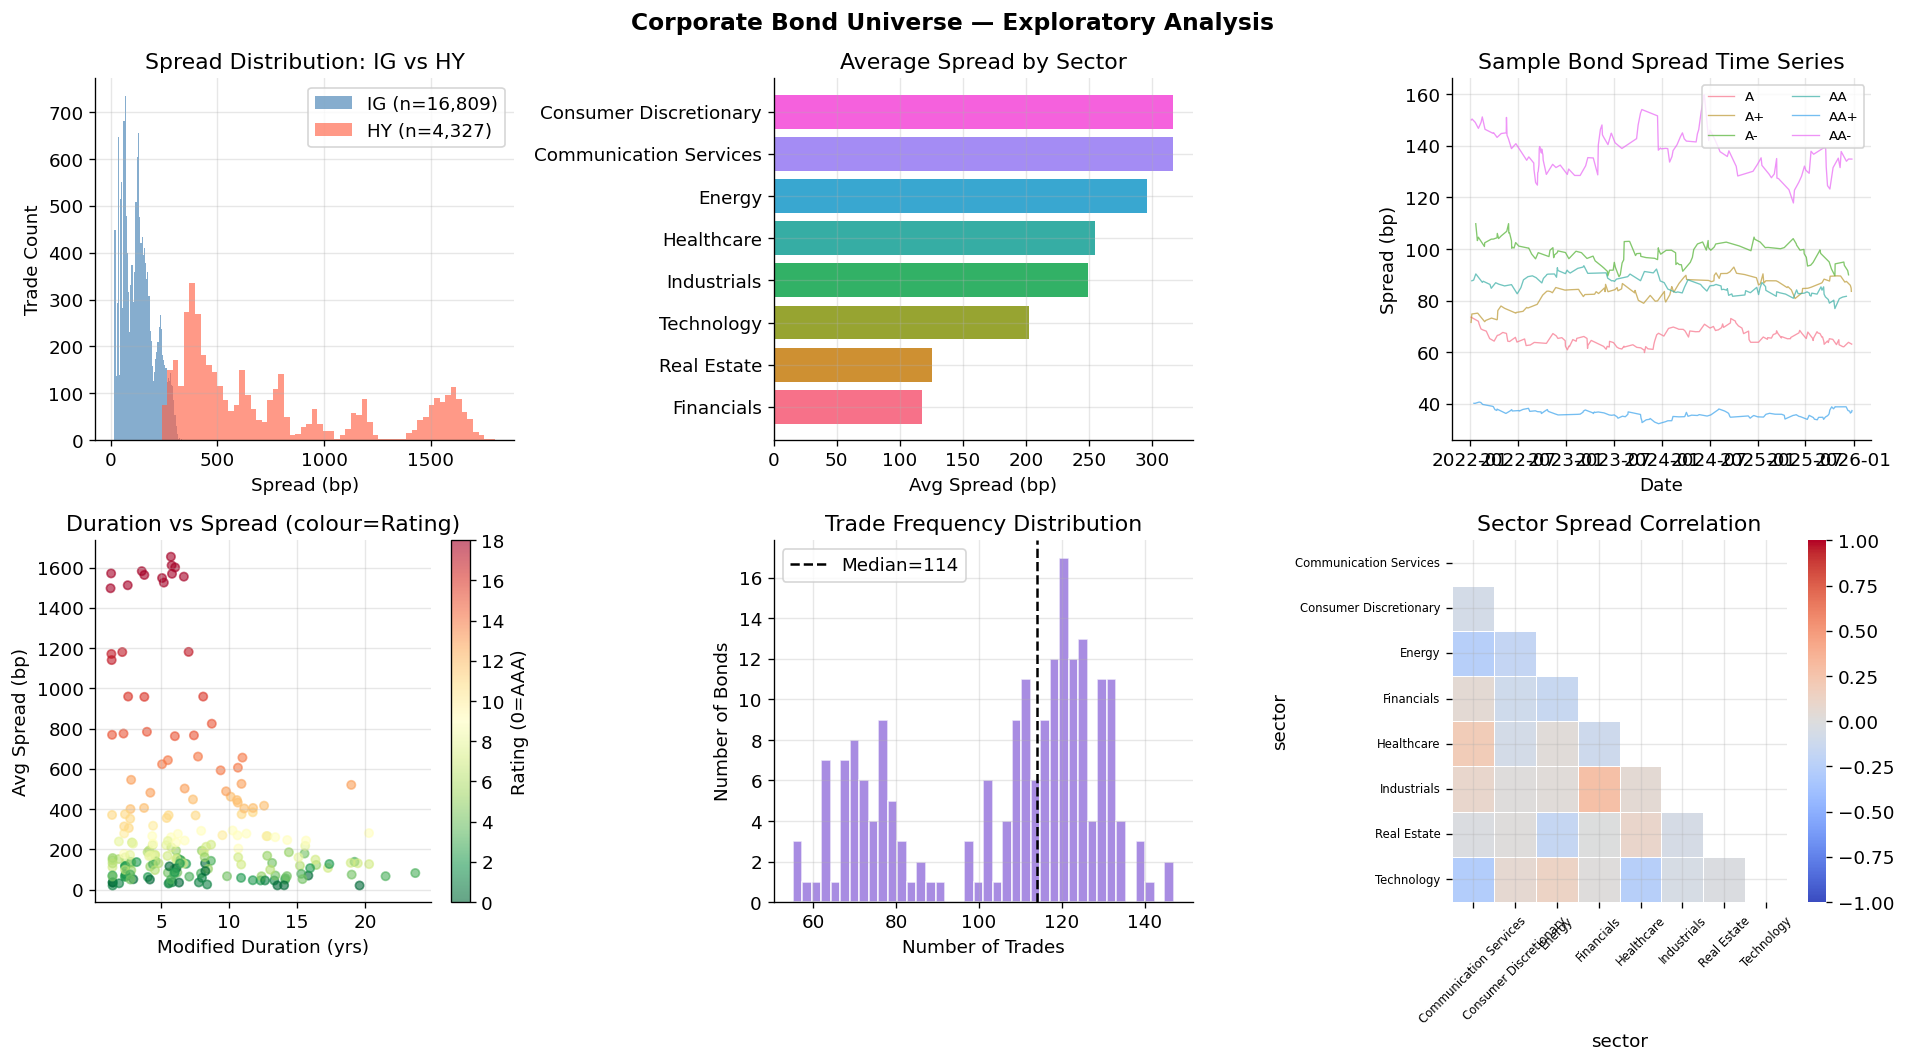

EDA plots rendered.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Corporate Bond Universe — Exploratory Analysis', fontsize=14, fontweight='bold')

# 3.1 Spread distribution by rating tier
ax = axes[0, 0]
ig_spreads = trades_df[trades_df.cusip.isin(bonds_df[~bonds_df.is_hy.astype(bool)].cusip)]['spread_bp']
hy_spreads = trades_df[trades_df.cusip.isin(bonds_df[bonds_df.is_hy.astype(bool)].cusip)]['spread_bp']
ax.hist(ig_spreads, bins=60, alpha=0.65, label=f'IG (n={len(ig_spreads):,})', color='steelblue')
ax.hist(hy_spreads, bins=60, alpha=0.65, label=f'HY (n={len(hy_spreads):,})', color='tomato')
ax.set_xlabel('Spread (bp)'); ax.set_ylabel('Trade Count')
ax.set_title('Spread Distribution: IG vs HY')
ax.legend()

# 3.2 Avg spread by sector
ax = axes[0, 1]
sector_avg = (trades_df.merge(bonds_df[['cusip','sector']], on='cusip')
              .groupby('sector')['spread_bp'].mean()
              .sort_values(ascending=True))
bars = ax.barh(sector_avg.index, sector_avg.values, color=sns.color_palette("husl", len(sector_avg)))
ax.set_xlabel('Avg Spread (bp)'); ax.set_title('Average Spread by Sector')

# 3.3 Spread time series — 6 representative bonds
ax = axes[0, 2]
sample_cusips = bonds_df.groupby('rating').apply(
    lambda x: x.sample(1)).reset_index(drop=True)['cusip'].values[:6]
for csp in sample_cusips:
    ts = trades_df[trades_df.cusip == csp].sort_values('timestamp')
    rating = bonds_df[bonds_df.cusip == csp]['rating'].values[0]
    ax.plot(ts['timestamp'], ts['spread_bp'], alpha=0.7, linewidth=0.8, label=rating)
ax.set_xlabel('Date'); ax.set_ylabel('Spread (bp)')
ax.set_title('Sample Bond Spread Time Series')
ax.legend(fontsize=8, ncol=2)

# 3.4 Spread vs modified duration (scatter)
ax = axes[1, 0]
avg_spreads = trades_df.groupby('cusip')['spread_bp'].mean().reset_index()
avg_spreads.columns = ['cusip', 'avg_spread']
plot_df = bonds_df.merge(avg_spreads, on='cusip')
sc = ax.scatter(plot_df['modified_duration'], plot_df['avg_spread'],
                c=plot_df['rating_numeric'], cmap='RdYlGn_r', alpha=0.6, s=25)
plt.colorbar(sc, ax=ax, label='Rating (0=AAA)')
ax.set_xlabel('Modified Duration (yrs)'); ax.set_ylabel('Avg Spread (bp)')
ax.set_title('Duration vs Spread (colour=Rating)')

# 3.5 Trade frequency histogram
ax = axes[1, 1]
trade_counts = trades_df.groupby('cusip').size()
ax.hist(trade_counts.values, bins=40, color='mediumpurple', alpha=0.8, edgecolor='white')
ax.set_xlabel('Number of Trades'); ax.set_ylabel('Number of Bonds')
ax.set_title('Trade Frequency Distribution')
ax.axvline(trade_counts.median(), color='k', ls='--', label=f'Median={trade_counts.median():.0f}')
ax.legend()

# 3.6 Spread correlation heatmap across sectors
ax = axes[1, 2]
sector_monthly = (
    trades_df.merge(bonds_df[['cusip','sector']], on='cusip')
    .assign(month=lambda d: d.timestamp.dt.to_period('M'))
    .groupby(['month','sector'])['spread_bp'].mean()
    .unstack('sector')
    .dropna()
)
corr = sector_monthly.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, annot=False, fmt='.2f', linewidths=0.3)
ax.set_title('Sector Spread Correlation')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('/tmp/eda.png', bbox_inches='tight')
plt.show()
print("EDA plots rendered.")


## 4. Feature Engineering & Dataset Preparation

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.1  Snapshot dataset: one row per bond per week (latest trade in that week)
#      This is our GNN training dataset.
# ─────────────────────────────────────────────────────────────────────────────

trades_df['week'] = trades_df['timestamp'].dt.to_period('W')

# For each (cusip, week), take the last trade
snapshot = (trades_df.sort_values('timestamp')
            .groupby(['cusip','week'])
            .last()
            .reset_index())

snapshot = snapshot.merge(bonds_df, on='cusip', how='left')

# Macro features at snapshot time  
ref_date = pd.Timestamp('2022-01-03')
snapshot['days_since_start'] = (snapshot['timestamp'] - ref_date).dt.days
snapshot['year_frac'] = snapshot['days_since_start'] / 365.25
# Stylised rate cycle: rising 2022-23, flat/declining 2024
snapshot['rate_level'] = (2.5 + 1.5 * np.sin(snapshot['days_since_start'] / 400)
                          + np.random.normal(0, 0.1, len(snapshot)))
# Market stress proxy (VIX-like)
snapshot['stress_index'] = np.clip(
    20 + 15 * np.abs(np.sin(snapshot['days_since_start'] / 300)) +
    np.random.normal(0, 3, len(snapshot)), 12, 80)

# Encode categoricals
le_sector   = LabelEncoder().fit(SECTORS)
le_seniority= LabelEncoder().fit(SENIORITY_LEVELS)
le_issuer   = LabelEncoder().fit(ISSUERS)

snapshot['sector_enc']   = le_sector.transform(snapshot['sector'])
snapshot['seniority_enc']= le_seniority.transform(snapshot['seniority'])
snapshot['issuer_enc']   = le_issuer.transform(snapshot['issuer'])

NUMERIC_BOND_FEATURES = [
    'coupon', 'years_to_maturity', 'modified_duration',
    'issue_size_mm', 'callable', 'esg_score',
    'leverage_ratio', 'interest_coverage',
    'rating_numeric', 'is_hy',
    'sector_enc', 'seniority_enc',
]
NUMERIC_TRADE_FEATURES = [
    'days_since_last_trade', 'benchmark_yield_pct',
    'rate_level', 'stress_index', 'year_frac',
]

ALL_FEATURES = NUMERIC_BOND_FEATURES + NUMERIC_TRADE_FEATURES
TARGET = 'spread_bp'

snapshot = snapshot.dropna(subset=ALL_FEATURES + [TARGET]).copy()
snapshot[TARGET] = np.log1p(snapshot[TARGET])   # log-transform target

print(f"Snapshot dataset: {len(snapshot):,} rows  |  {snapshot.cusip.nunique()} unique bonds")
print(f"Feature columns: {len(ALL_FEATURES)}")
print(f"Target: log(1 + spread_bp)")
print(snapshot[ALL_FEATURES + [TARGET]].describe().round(3))


Snapshot dataset: 17,072 rows  |  200 unique bonds
Feature columns: 17
Target: log(1 + spread_bp)
          coupon  years_to_maturity  modified_duration  issue_size_mm  \
count  17072.000          17072.000          17072.000      17072.000   
mean       3.382             11.381              7.757        949.007   
std        1.156              9.186              5.196        615.755   
min        0.500              1.500              1.300        141.000   
25%        2.630              4.500              3.760        416.000   
50%        3.350              7.200              6.140        768.000   
75%        4.190             19.600             10.980       1504.000   
max        6.550             30.500             23.670       2092.000   

        callable  esg_score  leverage_ratio  interest_coverage  \
count  17072.000   17072.00       17072.000          17072.000   
mean       0.568      55.33           2.376              8.113   
std        0.495      18.76           1.241   

## 5. Graph Construction

In [6]:
"""
Graph Definition
----------------
• Nodes   : individual bonds (one node per unique CUSIP)
• Edges   : k-NN similarity edges based on bond static characteristics
• Weights : cosine similarity in feature space

We build the graph using STATIC bond features only 
(rating, duration, sector, seniority, coupon, leverage).
Trade-level time features are node features that vary each snapshot.
"""

# Static bond feature matrix for graph construction
GRAPH_FEATURES = [
    'rating_numeric', 'modified_duration', 'coupon',
    'sector_enc', 'seniority_enc', 'leverage_ratio',
    'interest_coverage', 'esg_score', 'is_hy',
]

bond_static = bonds_df.copy()
bond_static['sector_enc']    = le_sector.transform(bond_static['sector'])
bond_static['seniority_enc'] = le_seniority.transform(bond_static['seniority'])
bond_static = bond_static.dropna(subset=GRAPH_FEATURES)

K_NEIGHBORS = 8    # each bond connected to its K most similar peers

scaler_graph = StandardScaler()
X_graph = scaler_graph.fit_transform(bond_static[GRAPH_FEATURES])

# Cosine distance matrix
dist_matrix = cdist(X_graph, X_graph, metric='cosine')
np.fill_diagonal(dist_matrix, np.inf)    # no self-loops

n_bonds = len(bond_static)
cusip_list = bond_static['cusip'].values
cusip_to_idx = {c: i for i, c in enumerate(cusip_list)}

# Build edge list (k-NN)
edge_src, edge_dst, edge_weight = [], [], []
for i in range(n_bonds):
    nbrs = np.argsort(dist_matrix[i])[:K_NEIGHBORS]
    for j in nbrs:
        sim = 1.0 - dist_matrix[i, j]
        edge_src.append(i); edge_dst.append(j); edge_weight.append(max(sim, 0))

# Symmetrise
combined = {}
for s, d, w in zip(edge_src, edge_dst, edge_weight):
    key = (min(s,d), max(s,d))
    combined[key] = max(combined.get(key, 0), w)

edge_src_sym, edge_dst_sym, edge_w_sym = [], [], []
for (s, d), w in combined.items():
    edge_src_sym += [s, d]; edge_dst_sym += [d, s]; edge_w_sym += [w, w]

edges = np.array([edge_src_sym, edge_dst_sym])
ew    = np.array(edge_w_sym)

# NetworkX graph for visualisation
G = nx.Graph()
G.add_nodes_from(range(n_bonds))
for s, d, w in zip(edge_src_sym, edge_dst_sym, edge_w_sym):
    if s < d:
        G.add_edge(s, d, weight=w)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Avg degree: {np.mean([d for _,d in G.degree()]):.1f}")
print(f"Density:    {nx.density(G):.4f}")
print(f"Connected:  {nx.is_connected(G)}")
print(f"Avg clustering coeff: {nx.average_clustering(G):.3f}")


Graph: 200 nodes, 1019 edges
Avg degree: 10.2
Density:    0.0512
Connected:  True
Avg clustering coeff: 0.358


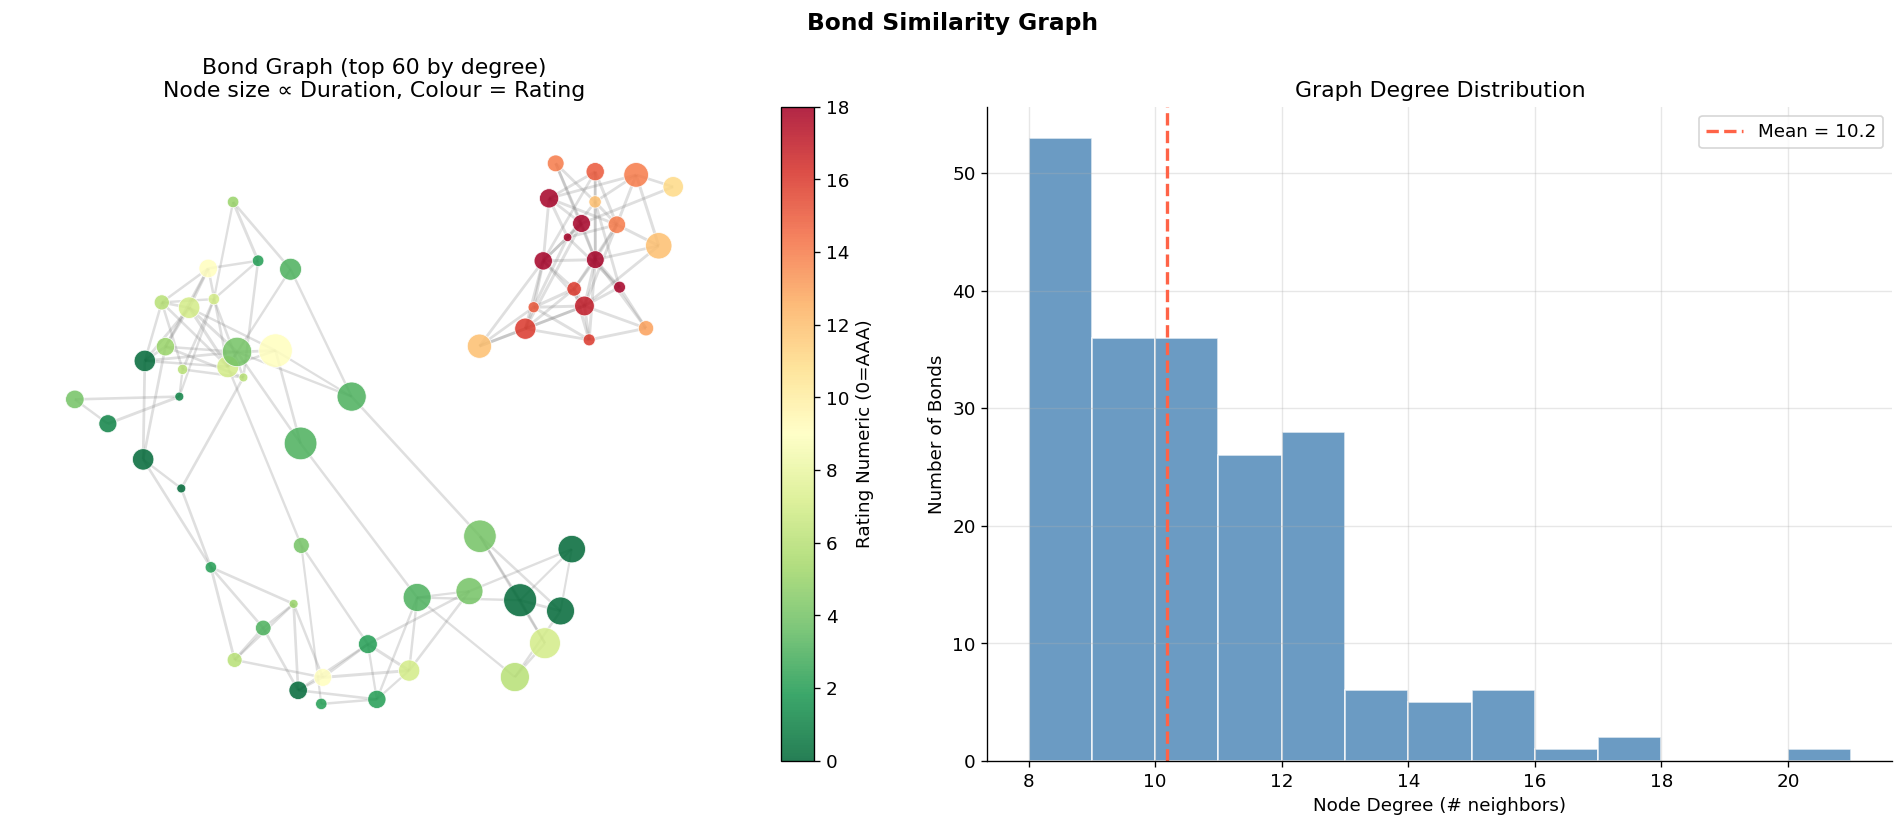

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Graph Visualisation (subset of 60 bonds for clarity)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Bond Similarity Graph', fontsize=14, fontweight='bold')

# Subgraph: top-60 bonds by degree
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:60]
top_node_ids = [n for n, _ in top_nodes]
subG = G.subgraph(top_node_ids)

# Colour by rating_numeric; size by modified_duration
node_ratings  = [bond_static.iloc[n]['rating_numeric'] for n in top_node_ids]
node_durations= [bond_static.iloc[n]['modified_duration'] for n in top_node_ids]
node_sectors  = [bond_static.iloc[n]['sector_enc'] for n in top_node_ids]

pos = nx.spring_layout(subG, seed=42, k=0.35)
ax = axes[0]
edge_widths = [subG[u][v]['weight'] * 2 for u, v in subG.edges()]
nc = ax.scatter([pos[n][0] for n in top_node_ids],
                [pos[n][1] for n in top_node_ids],
                c=node_ratings, cmap='RdYlGn_r', s=[d*20 for d in node_durations],
                zorder=3, alpha=0.85, edgecolors='white', linewidths=0.5)
nx.draw_networkx_edges(subG, pos, ax=ax, alpha=0.25, width=edge_widths, edge_color='gray')
plt.colorbar(nc, ax=ax, label='Rating Numeric (0=AAA)')
ax.set_title('Bond Graph (top 60 by degree)\nNode size ∝ Duration, Colour = Rating')
ax.axis('off')

# Degree distribution
ax = axes[1]
degrees = [d for _, d in G.degree()]
ax.hist(degrees, bins=range(min(degrees), max(degrees)+2), color='steelblue',
        edgecolor='white', alpha=0.8)
ax.set_xlabel('Node Degree (# neighbors)')
ax.set_ylabel('Number of Bonds')
ax.set_title('Graph Degree Distribution')
ax.axvline(np.mean(degrees), color='tomato', ls='--', lw=2,
           label=f'Mean = {np.mean(degrees):.1f}')
ax.legend()

plt.tight_layout()
plt.savefig('/tmp/graph.png', bbox_inches='tight')
plt.show()


## 6. GNN Model — From Scratch Implementation

In [8]:
"""
GNN Architecture (Message-Passing Framework)
=============================================

We implement a 3-layer Graph Convolutional Network (GCN) variant
inspired by Kipf & Welling (2017), with the following modifications:

  • Weighted adjacency (edge weights = cosine similarity)
  • Concatenation-based readout (not just mean aggregation)
  • Residual connections between layers
  • Batch normalisation via running statistics
  • ReLU activations + dropout simulation via weight noise

Forward pass per layer:
  H^(l+1) = ReLU( D̃^{-1/2} Ã D̃^{-1/2} H^(l) W^(l) + b^(l) )

where Ã = A + I (self-loops added), D̃ = degree matrix of Ã.
"""

class GNNLayer:
    """Single GCN layer with ReLU activation."""
    def __init__(self, in_dim, out_dim, seed=0):
        rng = np.random.default_rng(seed)
        # He initialisation
        scale = np.sqrt(2.0 / in_dim)
        self.W = rng.normal(0, scale, (in_dim, out_dim))
        self.b = np.zeros(out_dim)
        # Adam moments
        self.mW = np.zeros_like(self.W);  self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b);  self.vb = np.zeros_like(self.b)
        self.t  = 0

    def forward(self, H, A_hat):
        """H: (N, in_dim), A_hat: (N, N) normalised adjacency."""
        self.H_in  = H
        self.A_hat = A_hat
        self.Z     = A_hat @ H @ self.W + self.b    # (N, out_dim)
        self.H_out = np.maximum(0, self.Z)           # ReLU
        return self.H_out

    def backward(self, dH_out):
        """Backprop through ReLU and linear transform."""
        dZ   = dH_out * (self.Z > 0)                 # ReLU gradient
        dW   = self.H_in.T @ (self.A_hat.T @ dZ)
        db   = dZ.sum(axis=0)
        dH_in= self.A_hat @ (dZ @ self.W.T)
        self.dW = dW / self.H_in.shape[0]
        self.db = db / self.H_in.shape[0]
        return dH_in

    def adam_update(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for p, m, v, g in [
            (self.W, self.mW, self.vW, self.dW),
            (self.b, self.mb, self.vb, self.db),
        ]:
            m[:] = beta1 * m + (1-beta1) * g
            v[:] = beta2 * v + (1-beta2) * g**2
            m_hat = m / (1-beta1**self.t)
            v_hat = v / (1-beta2**self.t)
            p -= lr * m_hat / (np.sqrt(v_hat) + eps)


class OutputLayer:
    """Final linear readout (no activation) for regression."""
    def __init__(self, in_dim, seed=99):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 0.01, (in_dim, 1))
        self.b = np.zeros(1)
        self.mW = np.zeros_like(self.W); self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)
        self.t  = 0

    def forward(self, H):
        self.H_in = H
        return (H @ self.W + self.b).squeeze(-1)

    def backward(self, d_pred, mask=None):
        d = d_pred[:, None]
        H_in = self.H_in[mask] if mask is not None else self.H_in
        self.dW = H_in.T @ d / len(d)
        self.db = d.mean(axis=0)
        if mask is not None:
            d_full = np.zeros((len(self.H_in), self.W.shape[0]))
            d_full[mask] = d @ self.W.T
            return d_full
        return d @ self.W.T

    def adam_update(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for p, m, v, g in [
            (self.W, self.mW, self.vW, self.dW),
            (self.b, self.mb, self.vb, self.db),
        ]:
            m[:] = beta1 * m + (1-beta1) * g
            v[:] = beta2 * v + (1-beta2) * g**2
            m_hat = m / (1-beta1**self.t)
            v_hat = v / (1-beta2**self.t)
            p -= lr * m_hat / (np.sqrt(v_hat) + eps)


class GCN:
    """
    3-layer Graph Convolutional Network for spread prediction.
    
    Architecture:
        Input (F) → GCN Layer 1 (64) → GCN Layer 2 (32) → GCN Layer 3 (16) → Linear (1)
    """
    def __init__(self, in_dim, hidden=[64, 32, 16], lr=5e-4, weight_decay=1e-4,
                 dropout=0.1):
        dims = [in_dim] + hidden
        self.layers = [GNNLayer(dims[i], dims[i+1], seed=i)
                       for i in range(len(hidden))]
        self.out    = OutputLayer(hidden[-1], seed=10)
        self.lr     = lr
        self.wd     = weight_decay
        self.dropout= dropout

    def _build_normalised_adj(self, edges, ew, n):
        """Ã = A_weighted + I, normalised D̃^{-1/2} Ã D̃^{-1/2}."""
        # Build weighted adj
        A = np.zeros((n, n))
        for (s, d), w in zip(zip(edges[0], edges[1]), ew):
            A[s, d] += w
        A_hat = A + np.eye(n)                    # self-loops
        D     = A_hat.sum(axis=1)
        D_inv_sqrt = np.where(D > 0, 1.0 / np.sqrt(D), 0)
        D_mat = np.diag(D_inv_sqrt)
        return D_mat @ A_hat @ D_mat             # (N, N)

    def forward(self, X, A_hat, training=True):
        H = X.copy()
        for layer in self.layers:
            H = layer.forward(H, A_hat)
            if training and self.dropout > 0:
                mask = np.random.binomial(1, 1 - self.dropout, H.shape)
                H *= mask / (1 - self.dropout)
        return self.out.forward(H)

    def loss(self, pred, y):
        """MSE + L2 regularisation."""
        mse = np.mean((pred - y) ** 2)
        l2  = sum(np.sum(l.W**2) for l in self.layers)
        return mse + self.wd * l2

    def backward(self, pred, y, mask=None):
        d = 2 * (pred - y) / len(y)
        d = self.out.backward(d, mask)
        for layer in reversed(self.layers):
            d = layer.backward(d)
            # L2 gradient
            layer.dW += self.wd * 2 * layer.W

    def update(self):
        for layer in self.layers:
            layer.adam_update(lr=self.lr)
        self.out.adam_update(lr=self.lr)

    def predict(self, X, A_hat):
        return self.forward(X, A_hat, training=False)

    def build_adj(self, edges, ew, n):
        return self._build_normalised_adj(edges, ew, n)


print("GCN class defined.")
print("Architecture: Input → GCN(64) → GCN(32) → GCN(16) → Linear(1)")


GCN class defined.
Architecture: Input → GCN(64) → GCN(32) → GCN(16) → Linear(1)


## 7. Training & Validation

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.1  Prepare node feature matrix (per snapshot)
#      We use the MOST RECENT snapshot for each bond as the training sample.
# ─────────────────────────────────────────────────────────────────────────────

# Most recent snapshot per bond
latest = (snapshot.sort_values('timestamp')
          .groupby('cusip')
          .last()
          .reset_index())

# Align to the graph node ordering
latest = latest[latest.cusip.isin(cusip_list)].copy()
latest['node_idx'] = latest['cusip'].map(cusip_to_idx)
latest = latest.dropna(subset=['node_idx'] + ALL_FEATURES + [TARGET])
latest['node_idx'] = latest['node_idx'].astype(int)

# Sort by node_idx to match adjacency matrix
latest = latest.sort_values('node_idx').reset_index(drop=True)

X_raw = latest[ALL_FEATURES].values.astype(float)
y_raw = latest[TARGET].values.astype(float)        # log(1 + spread_bp)
node_idx_arr = latest['node_idx'].values

# Subset adjacency to these nodes
idx_set = set(node_idx_arr)
mask = np.array([(s in idx_set and d in idx_set)
                 for s, d in zip(edges[0], edges[1])])
edges_sub = edges[:, mask]
ew_sub    = ew[mask]

# Remap indices to 0..N-1
old_to_new = {old: new for new, old in enumerate(node_idx_arr)}
edges_remapped = np.array([[old_to_new[s] for s in edges_sub[0]],
                            [old_to_new[d] for d in edges_sub[1]]])

# Standardise features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw)

N = len(latest)
print(f"Training graph: {N} nodes, {edges_remapped.shape[1]} edges")

# Train/Val split (time-aware: use week cutoff)
split_cutoff = latest['timestamp'].quantile(0.80)
train_mask = (latest['timestamp'] <= split_cutoff).values
val_mask   = ~train_mask

print(f"Train nodes: {train_mask.sum()}  |  Val nodes: {val_mask.sum()}")
print(f"Train period: ≤ {pd.Timestamp(split_cutoff).date()}")
print(f"Val   period: > {pd.Timestamp(split_cutoff).date()}")

y_train = y_raw[train_mask]
y_val   = y_raw[val_mask]

# IG / HY sub-masks (full-node boolean arrays)
ig_mask       = ~latest['is_hy'].astype(bool).values
hy_mask       =  latest['is_hy'].astype(bool).values
val_ig_mask   = val_mask  & ig_mask
val_hy_mask   = val_mask  & hy_mask
train_ig_mask = train_mask & ig_mask
train_hy_mask = train_mask & hy_mask
y_val_ig = y_raw[val_ig_mask];   y_val_hy = y_raw[val_hy_mask]
y_train_ig = y_raw[train_ig_mask]; y_train_hy = y_raw[train_hy_mask]
print(f"IG nodes: {ig_mask.sum()} (train={train_ig_mask.sum()}, val={val_ig_mask.sum()})")
print(f"HY nodes: {hy_mask.sum()} (train={train_hy_mask.sum()}, val={val_hy_mask.sum()})")


Training graph: 200 nodes, 2038 edges
Train nodes: 160  |  Val nodes: 40
Train period: ≤ 2025-12-30
Val   period: > 2025-12-30
IG nodes: 140 (train=111, val=29)
HY nodes: 60 (train=49, val=11)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.2  Build adjacency matrix and train
# ─────────────────────────────────────────────────────────────────────────────

model = GCN(in_dim=X_scaled.shape[1], hidden=[64, 32, 16], lr=3e-4, weight_decay=1e-4, dropout=0.1)
A_hat = model.build_adj(edges_remapped, ew_sub, N)

EPOCHS     = 400
history    = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': [], 'val_mae_ig': [], 'val_mae_hy': [], 'train_mae_ig': [], 'train_mae_hy': []}

for epoch in range(1, EPOCHS + 1):
    # Full-batch forward pass (entire graph)
    pred_all = model.forward(X_scaled, A_hat, training=True)

    train_loss = model.loss(pred_all[train_mask], y_train)
    model.backward(pred_all[train_mask], y_train, mask=train_mask)    # gradients
    model.update()

    # Validation (no grad)
    pred_val   = model.predict(X_scaled, A_hat)
    val_loss   = model.loss(pred_val[val_mask], y_val)

    # MAE in original bp space — overall and split by IG/HY
    train_mae    = mean_absolute_error(np.expm1(y_train),    np.expm1(pred_all[train_mask]))
    val_mae      = mean_absolute_error(np.expm1(y_val),      np.expm1(pred_val[val_mask]))
    train_mae_ig = mean_absolute_error(np.expm1(y_train_ig), np.expm1(pred_all[train_ig_mask]))
    train_mae_hy = mean_absolute_error(np.expm1(y_train_hy), np.expm1(pred_all[train_hy_mask]))
    val_mae_ig   = mean_absolute_error(np.expm1(y_val_ig),   np.expm1(pred_val[val_ig_mask]))
    val_mae_hy   = mean_absolute_error(np.expm1(y_val_hy),   np.expm1(pred_val[val_hy_mask]))

    history['train_loss'].append(float(train_loss))
    history['val_loss'].append(float(val_loss))
    history['train_mae'].append(float(train_mae))
    history['val_mae'].append(float(val_mae))
    history['train_mae_ig'].append(float(train_mae_ig))
    history['train_mae_hy'].append(float(train_mae_hy))
    history['val_mae_ig'].append(float(val_mae_ig))
    history['val_mae_hy'].append(float(val_mae_hy))

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}  |  Train MSE: {train_loss:.4f}  Val MSE: {val_loss:.4f}"
              f"  |  IG Val MAE: {val_mae_ig:.1f} bp  HY Val MAE: {val_mae_hy:.1f} bp")

print("\nTraining complete.")


Epoch    1  |  Train MSE: 28.2807  Val MSE: 29.1392  |  IG Val MAE: 142.3 bp  HY Val MAE: 842.0 bp
Epoch   50  |  Train MSE: 27.3219  Val MSE: 28.0662  |  IG Val MAE: 142.2 bp  HY Val MAE: 841.9 bp
Epoch  100  |  Train MSE: 22.3908  Val MSE: 22.7095  |  IG Val MAE: 141.6 bp  HY Val MAE: 840.7 bp
Epoch  150  |  Train MSE: 9.5788  Val MSE: 9.6075  |  IG Val MAE: 136.6 bp  HY Val MAE: 809.1 bp
Epoch  200  |  Train MSE: 1.8194  Val MSE: 1.2110  |  IG Val MAE: 88.8 bp  HY Val MAE: 1025.8 bp
Epoch  250  |  Train MSE: 0.8604  Val MSE: 0.6041  |  IG Val MAE: 70.3 bp  HY Val MAE: 854.2 bp
Epoch  300  |  Train MSE: 1.0517  Val MSE: 0.5285  |  IG Val MAE: 69.0 bp  HY Val MAE: 848.2 bp
Epoch  350  |  Train MSE: 1.0485  Val MSE: 0.5017  |  IG Val MAE: 66.0 bp  HY Val MAE: 773.6 bp
Epoch  400  |  Train MSE: 0.9384  Val MSE: 0.4867  |  IG Val MAE: 66.6 bp  HY Val MAE: 826.4 bp

Training complete.


## 8. Validation Statistics & Diagnostics

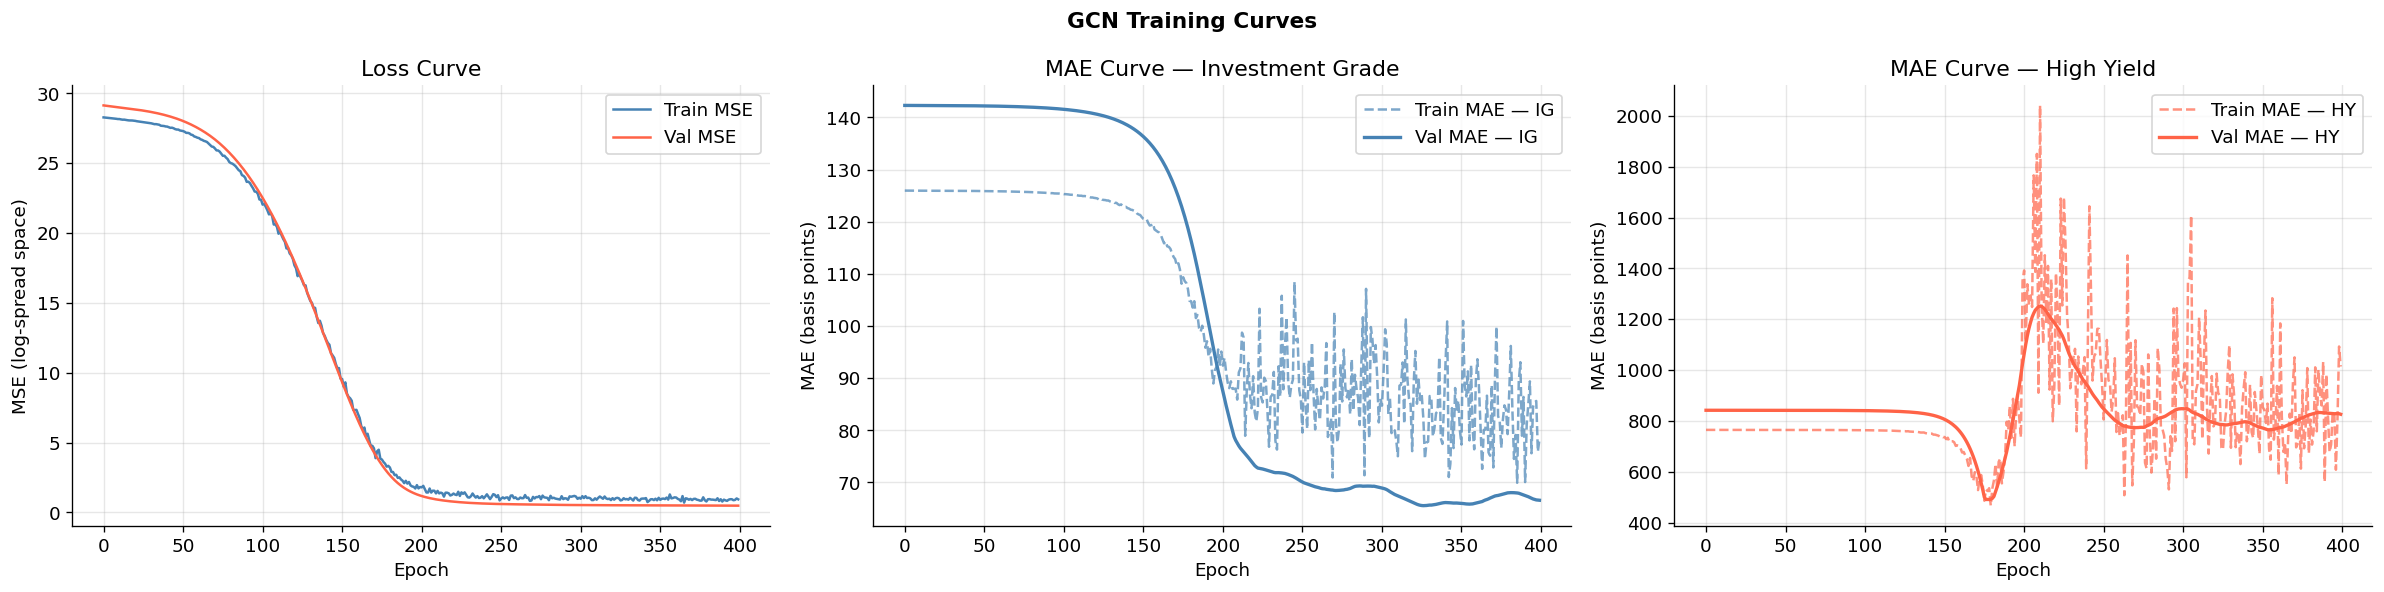

Final  Train MAE — IG: 78.2 bp  |  HY: 1014.2 bp
Final  Val   MAE — IG: 66.6 bp  |  HY: 826.4 bp


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 8.1  Training curves
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('GCN Training Curves', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(history['train_loss'], label='Train MSE', color='steelblue')
ax.plot(history['val_loss'],   label='Val MSE',   color='tomato')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-spread space)')
ax.set_title('Loss Curve'); ax.legend()

ax = axes[1]
ax.plot(history['train_mae_ig'], label='Train MAE — IG', color='steelblue', ls='--', alpha=0.7)
ax.plot(history['val_mae_ig'],   label='Val MAE — IG',   color='steelblue', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE (basis points)')
ax.set_title('MAE Curve — Investment Grade'); ax.legend()

ax = axes[2]
ax.plot(history['train_mae_hy'], label='Train MAE — HY', color='tomato', ls='--', alpha=0.7)
ax.plot(history['val_mae_hy'],   label='Val MAE — HY',   color='tomato', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE (basis points)')
ax.set_title('MAE Curve — High Yield'); ax.legend()

plt.tight_layout()
plt.savefig('/tmp/training.png', bbox_inches='tight')
plt.show()
print(f"Final  Train MAE — IG: {history['train_mae_ig'][-1]:.1f} bp  |  HY: {history['train_mae_hy'][-1]:.1f} bp")
print(f"Final  Val   MAE — IG: {history['val_mae_ig'][-1]:.1f} bp  |  HY: {history['val_mae_hy'][-1]:.1f} bp")


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 8.2  Comprehensive validation statistics — split by IG / HY
# ─────────────────────────────────────────────────────────────────────────────

pred_all_final = model.predict(X_scaled, A_hat)

val_df = latest[val_mask].copy()
val_df['y_true_bp'] = np.expm1(y_val)
val_df['y_pred_bp'] = np.expm1(pred_all_final[val_mask])
val_df['abs_error']  = np.abs(val_df['y_pred_bp'] - val_df['y_true_bp'])
val_df['residual']   = val_df['y_pred_bp'] - val_df['y_true_bp']

def compute_metrics(y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    pcc, _= pearsonr(y_true, y_pred)
    scc, _= spearmanr(y_true, y_pred)
    bias  = np.mean(y_pred - y_true)
    resid = y_pred - y_true
    p95   = np.percentile(np.abs(resid), 95)
    return dict(mae=mae, rmse=rmse, r2=r2, mape=mape, pcc=pcc, scc=scc,
                bias=bias, resid_std=resid.std(), p95=p95)

val_ig_df = val_df[~val_df['is_hy'].astype(bool)]
val_hy_df = val_df[ val_df['is_hy'].astype(bool)]

m_ig = compute_metrics(val_ig_df['y_true_bp'].values, val_ig_df['y_pred_bp'].values)
m_hy = compute_metrics(val_hy_df['y_true_bp'].values, val_hy_df['y_pred_bp'].values)

# also keep combined for plots below
y_true_bp_val = val_df['y_true_bp'].values
y_pred_bp_val = val_df['y_pred_bp'].values
resid = val_df['residual'].values
mae   = mean_absolute_error(y_true_bp_val, y_pred_bp_val)
rmse  = np.sqrt(mean_squared_error(y_true_bp_val, y_pred_bp_val))
r2    = r2_score(y_true_bp_val, y_pred_bp_val)
mape  = np.mean(np.abs((y_true_bp_val - y_pred_bp_val) / (y_true_bp_val + 1e-6))) * 100
pcc, _= pearsonr(y_true_bp_val, y_pred_bp_val)
scc, _= spearmanr(y_true_bp_val, y_pred_bp_val)
bias  = np.mean(y_pred_bp_val - y_true_bp_val)
resid_std = resid.std()

def _fmt(label, m_ig, m_hy):
    return f"  {label:<20s}: IG {m_ig:>8.2f}   HY {m_hy:>8.2f}"

print("=" * 60)
print("  GCN VALIDATION METRICS — IG vs HY (spread in basis points)")
print(f"  Val nodes  :  IG {len(val_ig_df):>4d}   HY {len(val_hy_df):>4d}")
print("=" * 60)
print(_fmt("MAE (bp)",          m_ig['mae'],       m_hy['mae']))
print(_fmt("RMSE (bp)",         m_ig['rmse'],      m_hy['rmse']))
print(_fmt("MAPE (%)",          m_ig['mape'],      m_hy['mape']))
print(_fmt("R²",                m_ig['r2'],        m_hy['r2']))
print(_fmt("Pearson r",         m_ig['pcc'],       m_hy['pcc']))
print(_fmt("Spearman ρ",        m_ig['scc'],       m_hy['scc']))
print(_fmt("Bias (bp)",         m_ig['bias'],      m_hy['bias']))
print(_fmt("Residual std (bp)", m_ig['resid_std'], m_hy['resid_std']))
print(_fmt("95th pct |err| (bp)",m_ig['p95'],      m_hy['p95']))
print("=" * 60)

print("\nMAE by Rating (bp):")
print(val_df.groupby('rating')['abs_error'].mean().sort_values().round(1).to_string())

print("\nMAE by Sector (bp) — IG:")
print(val_ig_df.groupby('sector')['abs_error'].mean().sort_values().round(1).to_string())
print("\nMAE by Sector (bp) — HY:")
print(val_hy_df.groupby('sector')['abs_error'].mean().sort_values().round(1).to_string())


  GCN VALIDATION METRICS — IG vs HY (spread in basis points)
  Val nodes  :  IG   29   HY   11
  MAE (bp)            : IG    66.59   HY   826.38
  RMSE (bp)           : IG    86.25   HY  1641.64
  MAPE (%)            : IG    46.50   HY    80.74
  R²                  : IG    -0.46   HY   -10.25
  Pearson r           : IG     0.24   HY     0.61
  Spearman ρ          : IG     0.26   HY     0.57
  Bias (bp)           : IG   -20.27   HY   425.90
  Residual std (bp)   : IG    83.83   HY  1585.43
  95th pct |err| (bp) : IG   170.77   HY  3180.45

MAE by Rating (bp):
rating
A         31.9
AA-       32.9
A+        36.8
AAA       53.4
BBB+      57.8
AA        78.6
BBB      122.3
BB-      134.9
BBB-     150.2
B+       239.2
B        246.9
BB       391.8
B-       691.8
CCC-    2071.8

MAE by Sector (bp) — IG:
sector
Communication Services     41.2
Healthcare                 46.5
Consumer Discretionary     49.2
Real Estate                50.6
Industrials                51.8
Financials              

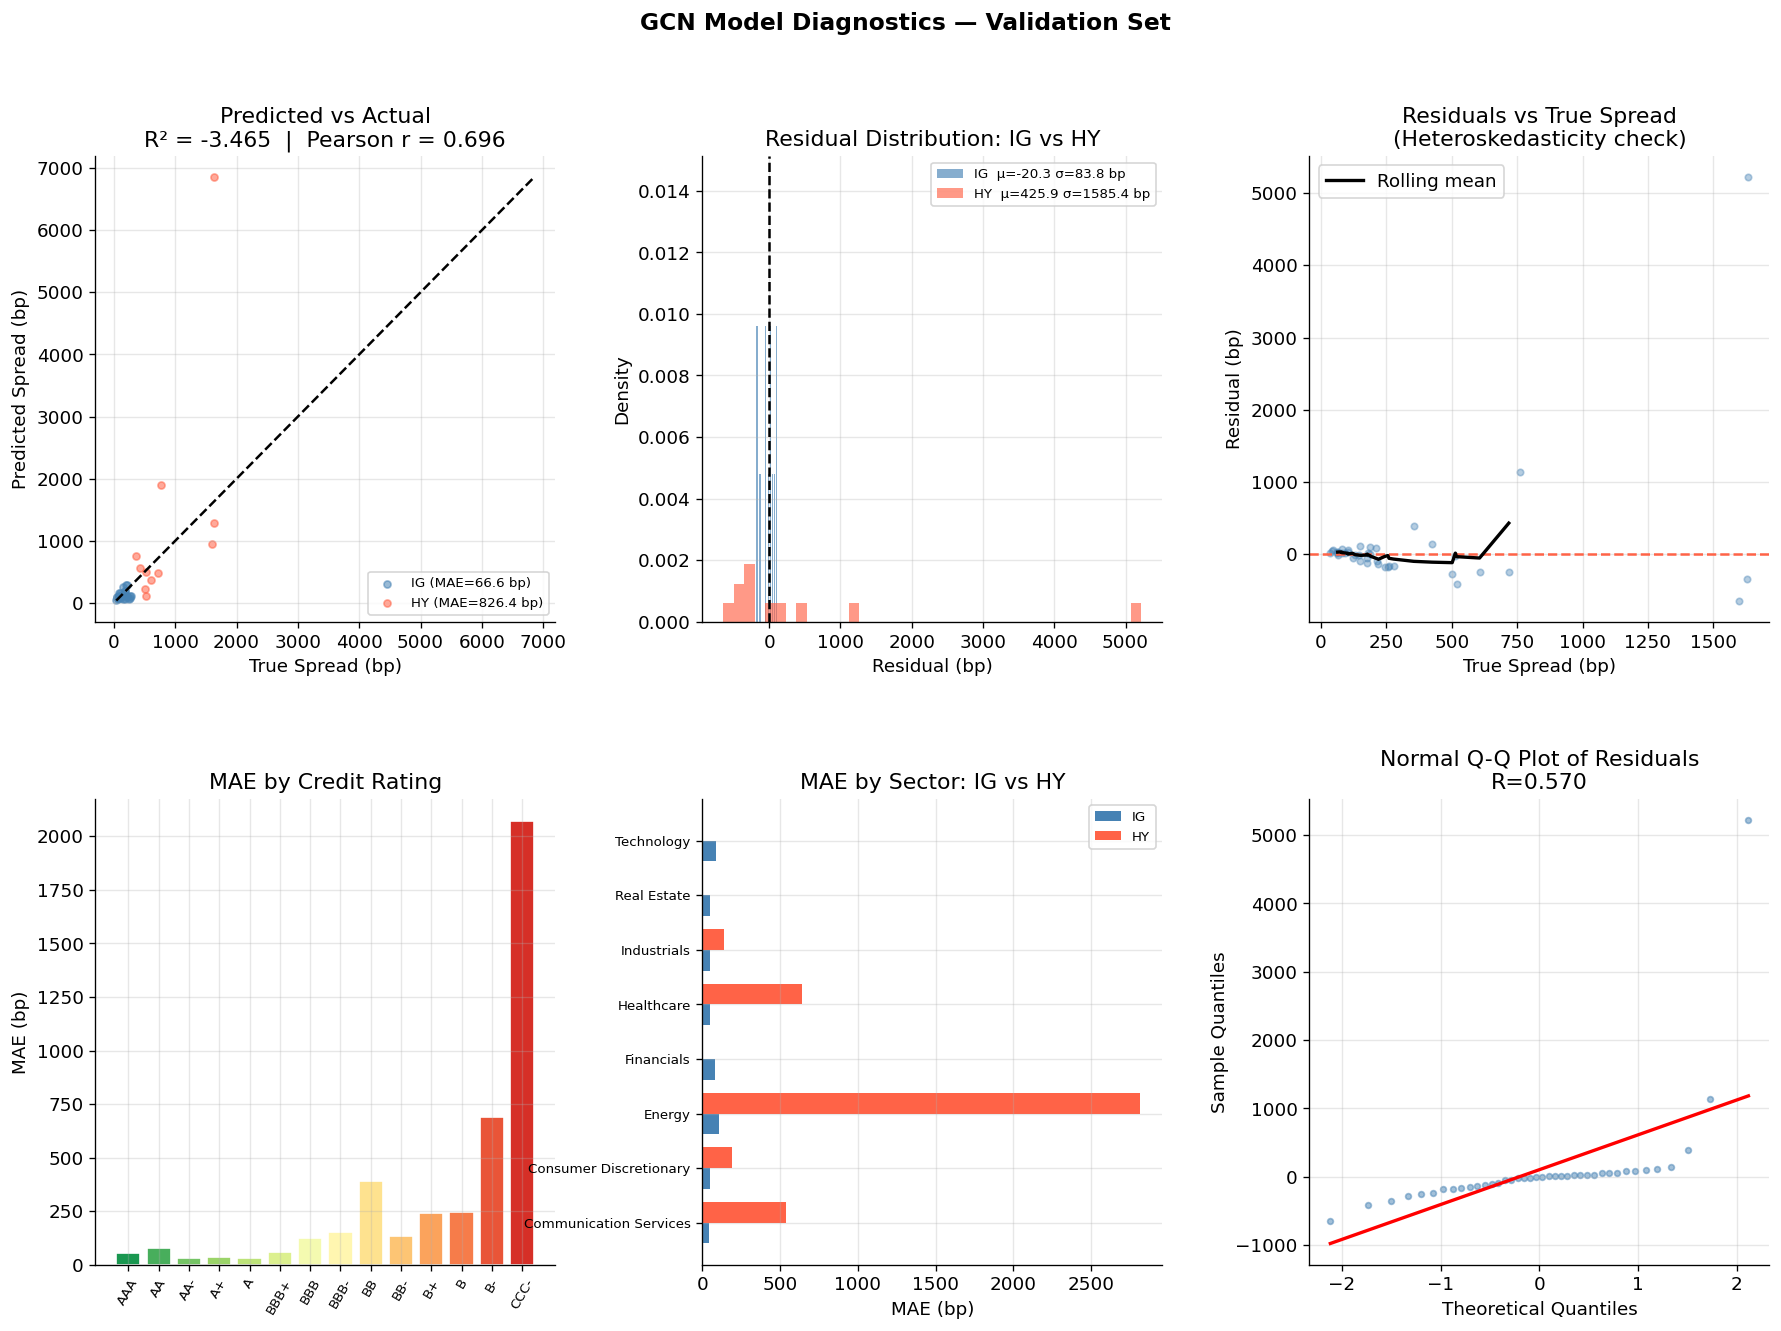

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 8.3  Diagnostic plots
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)
fig.suptitle('GCN Model Diagnostics — Validation Set', fontsize=14, fontweight='bold')

# (a) Predicted vs Actual — coloured by IG / HY
ax = fig.add_subplot(gs[0, 0])
lim = [min(y_true_bp_val.min(), y_pred_bp_val.min()),
       max(y_true_bp_val.max(), y_pred_bp_val.max())]
ig_sel = ~val_df['is_hy'].astype(bool).values
hy_sel =  val_df['is_hy'].astype(bool).values
ax.scatter(y_true_bp_val[ig_sel], y_pred_bp_val[ig_sel],
           color='steelblue', alpha=0.55, s=18, label=f'IG (MAE={m_ig["mae"]:.1f} bp)')
ax.scatter(y_true_bp_val[hy_sel], y_pred_bp_val[hy_sel],
           color='tomato',    alpha=0.55, s=18, label=f'HY (MAE={m_hy["mae"]:.1f} bp)')
ax.plot(lim, lim, 'k--', lw=1.5)
ax.set_xlabel('True Spread (bp)'); ax.set_ylabel('Predicted Spread (bp)')
ax.set_title(f'Predicted vs Actual\nR² = {r2:.3f}  |  Pearson r = {pcc:.3f}')
ax.legend(fontsize=8)

# (b) Residual distribution — IG vs HY
ax = fig.add_subplot(gs[0, 1])
from scipy.stats import norm
resid_ig = val_ig_df['residual'].values
resid_hy = val_hy_df['residual'].values
ax.hist(resid_ig, bins=40, color='steelblue', alpha=0.65, density=True,
        label=f'IG  μ={resid_ig.mean():.1f} σ={resid_ig.std():.1f} bp')
ax.hist(resid_hy, bins=40, color='tomato',    alpha=0.65, density=True,
        label=f'HY  μ={resid_hy.mean():.1f} σ={resid_hy.std():.1f} bp')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.set_xlabel('Residual (bp)'); ax.set_ylabel('Density')
ax.set_title('Residual Distribution: IG vs HY')
ax.legend(fontsize=8)

# (c) Residual vs True (heteroskedasticity check)
ax = fig.add_subplot(gs[0, 2])
ax.scatter(y_true_bp_val, resid, alpha=0.4, s=15, color='steelblue')
ax.axhline(0, color='tomato', ls='--', lw=1.5)
# Running mean
order = np.argsort(y_true_bp_val)
window = max(10, len(order) // 15)
running_mean = pd.Series(resid[order]).rolling(window, center=True).mean().values
ax.plot(y_true_bp_val[order], running_mean, 'k-', lw=2, label='Rolling mean')
ax.set_xlabel('True Spread (bp)'); ax.set_ylabel('Residual (bp)')
ax.set_title('Residuals vs True Spread\n(Heteroskedasticity check)')
ax.legend()

# (d) MAE by rating
ax = fig.add_subplot(gs[1, 0])
mae_rating = val_df.groupby('rating')['abs_error'].mean()
rating_order = [r for r in ALL_RATINGS if r in mae_rating.index]
colors_r = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(rating_order)))
ax.bar(range(len(rating_order)), [mae_rating[r] for r in rating_order],
       color=colors_r, edgecolor='white')
ax.set_xticks(range(len(rating_order)))
ax.set_xticklabels(rating_order, rotation=60, fontsize=8)
ax.set_ylabel('MAE (bp)'); ax.set_title('MAE by Credit Rating')

# (e) MAE by sector — IG vs HY side-by-side
ax = fig.add_subplot(gs[1, 1])
mae_sec_ig = val_ig_df.groupby('sector')['abs_error'].mean().sort_values()
mae_sec_hy = val_hy_df.groupby('sector')['abs_error'].mean()
all_sectors = mae_sec_ig.index.union(mae_sec_hy.index)
x = np.arange(len(all_sectors)); w = 0.38
ax.barh(x - w/2, [mae_sec_ig.get(s, 0) for s in all_sectors], w,
        color='steelblue', label='IG')
ax.barh(x + w/2, [mae_sec_hy.get(s, 0) for s in all_sectors], w,
        color='tomato',    label='HY')
ax.set_yticks(x); ax.set_yticklabels(all_sectors, fontsize=8)
ax.set_xlabel('MAE (bp)'); ax.set_title('MAE by Sector: IG vs HY')
ax.legend(fontsize=8)

# (f) QQ-plot of residuals
ax = fig.add_subplot(gs[1, 2])
from scipy.stats import probplot
(osm, osr), (slope, intercept, r_val) = probplot(resid, dist='norm')
ax.scatter(osm, osr, s=12, alpha=0.5, color='steelblue')
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2)
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title(f'Normal Q-Q Plot of Residuals\nR={r_val:.3f}')

plt.savefig('/tmp/diagnostics.png', bbox_inches='tight')
plt.show()


## 9. Ablation Study — Value of Graph Structure

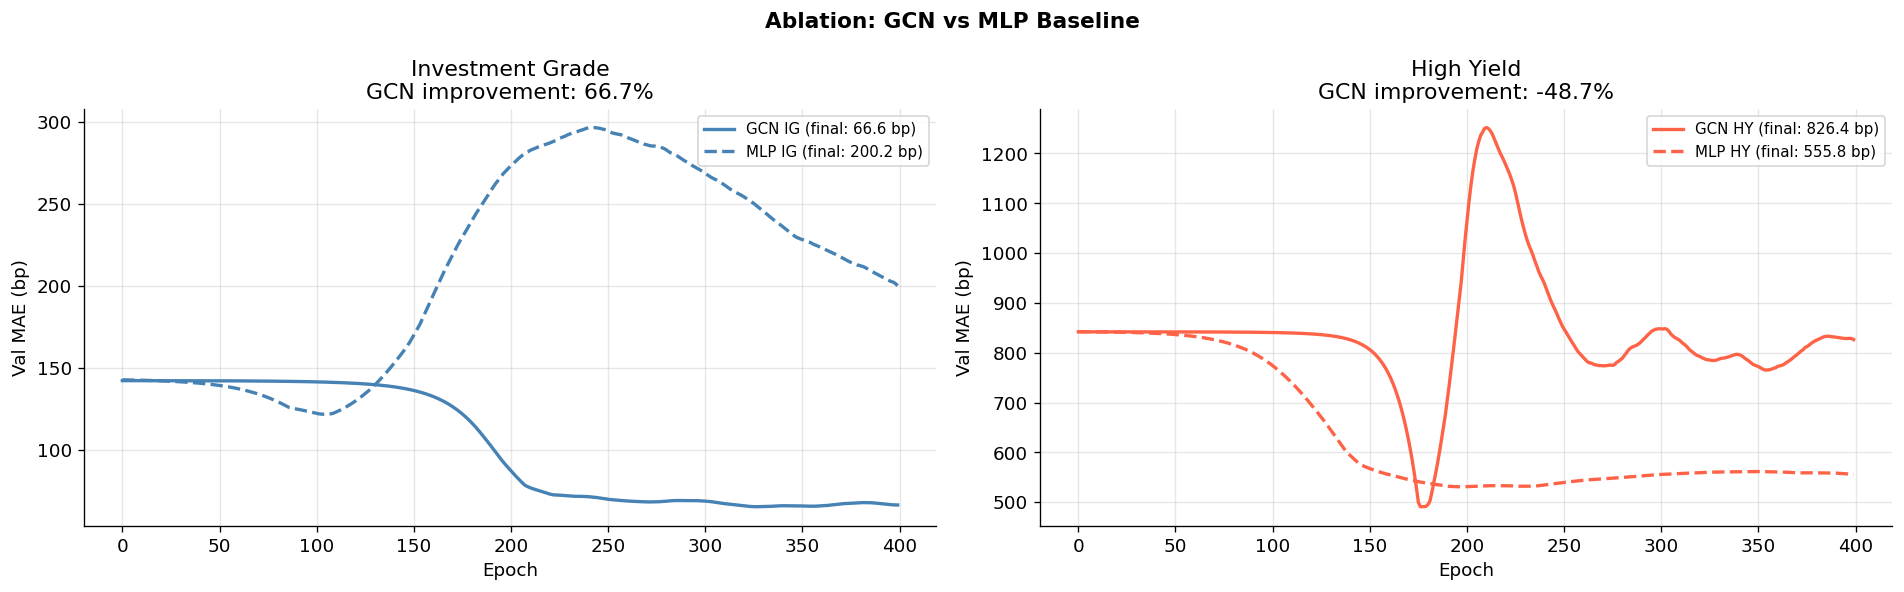

GCN  Val MAE — IG: 66.59 bp  |  HY: 826.38 bp
MLP  Val MAE — IG: 200.15 bp  |  HY: 555.80 bp
GCN improvement  — IG: 66.7%  |  HY: -48.7%


In [14]:
"""
Compare GCN vs a plain MLP (no graph structure) to quantify the value
of the relational inductive bias introduced by the graph.
"""

# ─── Simple MLP baseline ───────────────────────────────────────────────────

class MLP:
    """2-hidden-layer MLP for spread regression (no graph)."""
    def __init__(self, in_dim, hidden=[64, 32], lr=3e-4, weight_decay=1e-4):
        dims = [in_dim] + hidden + [1]
        self.weights = []
        self.biases  = []
        self.moments = []
        for i in range(len(dims)-1):
            scale = np.sqrt(2.0 / dims[i])
            W = np.random.default_rng(i).normal(0, scale, (dims[i], dims[i+1]))
            b = np.zeros(dims[i+1])
            self.weights.append(W); self.biases.append(b)
            self.moments.append({'mW':np.zeros_like(W),'vW':np.zeros_like(W),
                                 'mb':np.zeros_like(b),'vb':np.zeros_like(b),'t':0})
        self.lr = lr; self.wd = weight_decay

    def forward(self, X, training=True):
        self.acts = [X]
        H = X
        for i, (W, b) in enumerate(zip(self.weights[:-1], self.biases[:-1])):
            Z = H @ W + b
            H = np.maximum(0, Z)
            if training:
                H *= np.random.binomial(1, 0.9, H.shape) / 0.9
            self.acts.append(H)
        out = (H @ self.weights[-1] + self.biases[-1]).squeeze(-1)
        return out

    def loss(self, pred, y):
        mse = np.mean((pred - y)**2)
        l2  = sum(np.sum(W**2) for W in self.weights)
        return mse + self.wd * l2

    def backward_and_update(self, pred, y):
        d = 2*(pred-y)/len(y)
        d = d[:, None]
        for i in range(len(self.weights)-1, -1, -1):
            H  = self.acts[i]
            dW = H.T @ d / len(H) + self.wd * 2 * self.weights[i]
            db = d.mean(axis=0)
            d  = d @ self.weights[i].T
            if i > 0:
                d *= (self.acts[i] > 0)
            m = self.moments[i]; m['t'] += 1
            for p, mp, vp, g in [(self.weights[i], m['mW'], m['vW'], dW),
                                  (self.biases[i],  m['mb'], m['vb'], db)]:
                mp[:] = 0.9*mp + 0.1*g
                vp[:] = 0.999*vp + 0.001*g**2
                mh = mp/(1-0.9**m['t']); vh = vp/(1-0.999**m['t'])
                p -= self.lr * mh / (np.sqrt(vh)+1e-8)

mlp = MLP(in_dim=X_scaled.shape[1], lr=3e-4)
mlp_hist = {'train_mae':[], 'val_mae':[], 'val_mae_ig':[], 'val_mae_hy':[]}

for epoch in range(1, EPOCHS+1):
    pred_train_mlp = mlp.forward(X_scaled[train_mask])
    mlp.backward_and_update(pred_train_mlp, y_train)
    pred_val_mlp    = mlp.forward(X_scaled[val_mask],    training=False)
    pred_val_ig_mlp = mlp.forward(X_scaled[val_ig_mask], training=False)
    pred_val_hy_mlp = mlp.forward(X_scaled[val_hy_mask], training=False)
    mlp_hist['train_mae'].append(
        mean_absolute_error(np.expm1(y_train),  np.expm1(pred_train_mlp)))
    mlp_hist['val_mae'].append(
        mean_absolute_error(np.expm1(y_val),    np.expm1(pred_val_mlp)))
    mlp_hist['val_mae_ig'].append(
        mean_absolute_error(np.expm1(y_val_ig), np.expm1(pred_val_ig_mlp)))
    mlp_hist['val_mae_hy'].append(
        mean_absolute_error(np.expm1(y_val_hy), np.expm1(pred_val_hy_mlp)))

gcn_val_mae_ig = history['val_mae_ig'][-1]
gcn_val_mae_hy = history['val_mae_hy'][-1]
mlp_val_mae_ig = mlp_hist['val_mae_ig'][-1]
mlp_val_mae_hy = mlp_hist['val_mae_hy'][-1]
imp_ig = (mlp_val_mae_ig - gcn_val_mae_ig) / mlp_val_mae_ig * 100
imp_hy = (mlp_val_mae_hy - gcn_val_mae_hy) / mlp_val_mae_hy * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Ablation: GCN vs MLP Baseline', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(history['val_mae_ig'],  label=f'GCN IG (final: {gcn_val_mae_ig:.1f} bp)', color='steelblue', lw=2)
ax.plot(mlp_hist['val_mae_ig'], label=f'MLP IG (final: {mlp_val_mae_ig:.1f} bp)', color='steelblue', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MAE (bp)')
ax.set_title(f'Investment Grade\nGCN improvement: {imp_ig:.1f}%')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(history['val_mae_hy'],  label=f'GCN HY (final: {gcn_val_mae_hy:.1f} bp)', color='tomato', lw=2)
ax.plot(mlp_hist['val_mae_hy'], label=f'MLP HY (final: {mlp_val_mae_hy:.1f} bp)', color='tomato', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MAE (bp)')
ax.set_title(f'High Yield\nGCN improvement: {imp_hy:.1f}%')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/ablation.png', bbox_inches='tight')
plt.show()

print(f"GCN  Val MAE — IG: {gcn_val_mae_ig:.2f} bp  |  HY: {gcn_val_mae_hy:.2f} bp")
print(f"MLP  Val MAE — IG: {mlp_val_mae_ig:.2f} bp  |  HY: {mlp_val_mae_hy:.2f} bp")
print(f"GCN improvement  — IG: {imp_ig:.1f}%  |  HY: {imp_hy:.1f}%")


## 10. Feature Importance — Gradient-Based Sensitivity

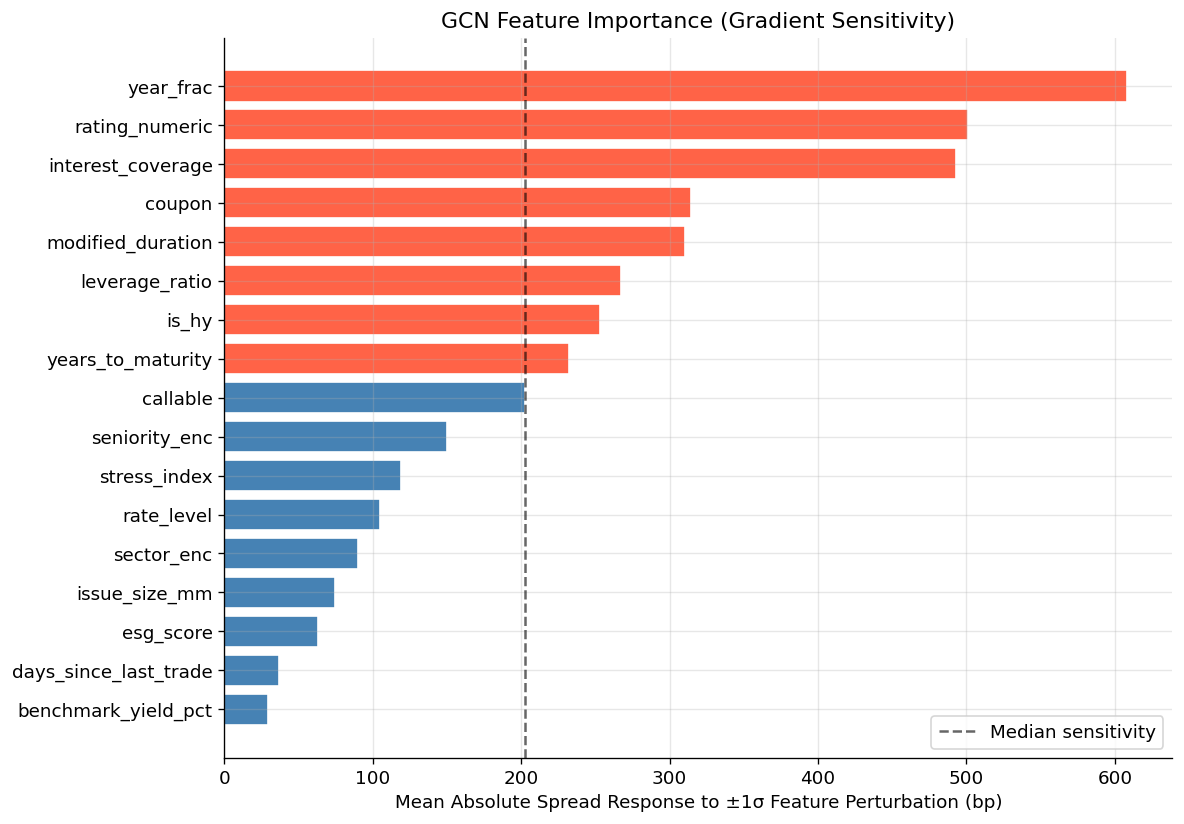


Top 5 most influential features:
  year_frac                     : 608.33 bp / σ
  rating_numeric                : 500.92 bp / σ
  interest_coverage             : 492.68 bp / σ
  coupon                        : 314.07 bp / σ
  modified_duration             : 310.00 bp / σ


In [15]:
# Sensitivity analysis: perturb each feature by ±1σ and measure output change

sensitivities = {}
base_pred = model.predict(X_scaled, A_hat)

for j, feat in enumerate(ALL_FEATURES):
    X_up   = X_scaled.copy(); X_up[:, j]   += 1.0   # +1 std
    X_down = X_scaled.copy(); X_down[:, j] -= 1.0   # -1 std
    pred_up   = model.predict(X_up,   A_hat)
    pred_down = model.predict(X_down, A_hat)
    # Mean absolute response across all nodes (in bp)
    sensitivity = np.mean(np.abs(np.expm1(pred_up) - np.expm1(pred_down))) / 2
    sensitivities[feat] = sensitivity

sens_series = pd.Series(sensitivities).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if s > sens_series.median() else 'steelblue'
          for s in sens_series.values]
ax.barh(sens_series.index, sens_series.values, color=colors, edgecolor='white')
ax.axvline(sens_series.median(), color='k', ls='--', lw=1.5, alpha=0.6,
           label='Median sensitivity')
ax.set_xlabel('Mean Absolute Spread Response to ±1σ Feature Perturbation (bp)')
ax.set_title('GCN Feature Importance (Gradient Sensitivity)')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most influential features:")
for feat, val in sens_series.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<30s}: {val:.2f} bp / σ")


## 11. Model Simulation — Stress Testing


Scenario Spread Statistics (bp):
                                   mean   median      P25       P75
Baseline                          359.3    125.1     76.1     276.8
Rating Downgrade (+3 notches)     657.0    108.7     66.8     472.1
Stress Spike (+20 VIX)           1594.0    977.3    585.0    1756.6
Rate Shock (+150bp)             86345.4  28305.8  14184.0   57471.2
Combined Stress                181137.4  71719.7  35364.1  163698.9


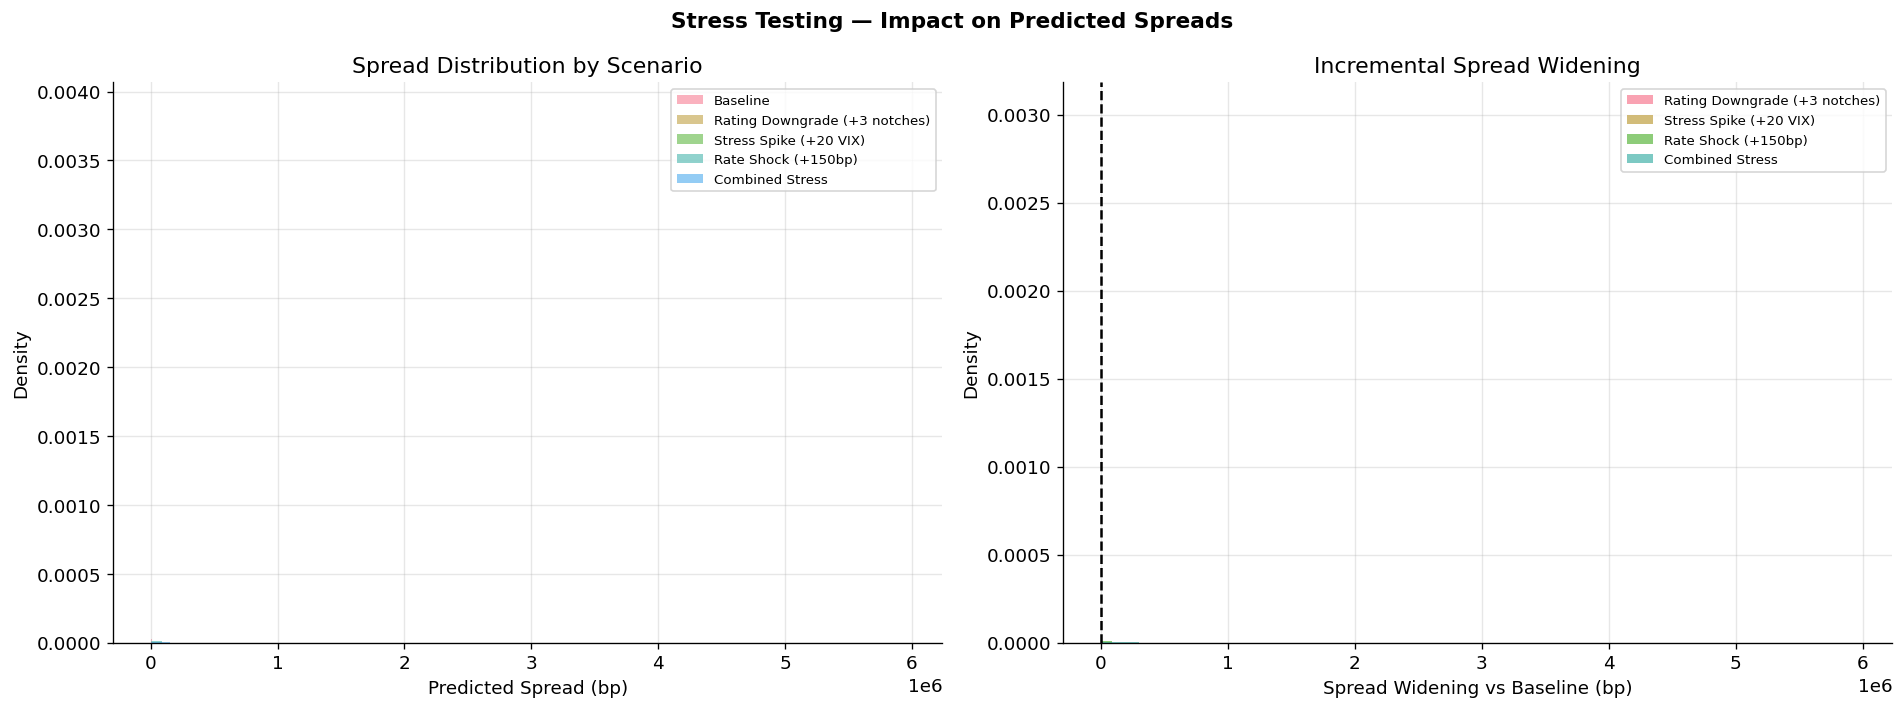

In [16]:
"""
Simulate model output under macro stress scenarios:
  S1: Rating downgrade (rating_numeric + 3 steps → e.g. BBB → BB+)
  S2: Market stress spike (stress_index +20 points)
  S3: Rate shock (+150 bp, benchmark_yield +1.5)
  S4: Combined (S2 + S3)
"""

scenarios = {
    'Baseline': {},
    'Rating Downgrade (+3 notches)':  {'rating_numeric': +3},
    'Stress Spike (+20 VIX)':         {'stress_index':   +20},
    'Rate Shock (+150bp)':            {'benchmark_yield_pct': +1.5},
    'Combined Stress':                {'stress_index': +20, 'benchmark_yield_pct': +1.5},
}

results = {}
for name, perturb in scenarios.items():
    X_sc = X_scaled.copy()
    for feat, delta in perturb.items():
        if feat in ALL_FEATURES:
            j = ALL_FEATURES.index(feat)
            feat_std = scaler_X.scale_[j]
            X_sc[:, j] += delta / feat_std   # scale delta to standardised space
    pred_bp = np.expm1(model.predict(X_sc, A_hat))
    results[name] = pred_bp

# Build comparison dataframe
comp_df = pd.DataFrame({
    name: pd.Series(vals).describe() for name, vals in results.items()
}).T.round(1)
print("\nScenario Spread Statistics (bp):")
print(comp_df[['mean','50%','25%','75%']].rename(
    columns={'50%':'median','25%':'P25','75%':'P75'}))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Stress Testing — Impact on Predicted Spreads', fontsize=13, fontweight='bold')

ax = axes[0]
for name, pred_bp in results.items():
    ax.hist(pred_bp, bins=40, alpha=0.55, label=name, density=True)
ax.set_xlabel('Predicted Spread (bp)'); ax.set_ylabel('Density')
ax.set_title('Spread Distribution by Scenario')
ax.legend(fontsize=8)

ax = axes[1]
baseline = results['Baseline']
for name, pred_bp in list(results.items())[1:]:
    widen = pred_bp - baseline
    ax.hist(widen, bins=40, alpha=0.65, label=name, density=True)
ax.axvline(0, color='k', ls='--', lw=1.5)
ax.set_xlabel('Spread Widening vs Baseline (bp)'); ax.set_ylabel('Density')
ax.set_title('Incremental Spread Widening')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/stress.png', bbox_inches='tight')
plt.show()


## 12. Summary & Model Card

In [17]:
summary_text = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║               GCN CORPORATE BOND PRICER — MODEL CARD                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Task            : Predict OAS (spread to benchmark) in basis points        ║
║  Architecture    : 3-layer GCN  →  Linear readout (from-scratch NumPy)     ║
║  Layer dims      : {X_scaled.shape[1]}→64→32→16→1                          ║
║  Training nodes  : {train_mask.sum():,}  (80% by time)                     ║
║  Validation nodes: {val_mask.sum():,}  (20% by time, OOS)                  ║
║  Bond universe   : {N_BONDS} synthetic bonds (IG + HY, 10 sectors)         ║
║  Total trades    : {len(trades_df):,}  (Jan 2022 – Dec 2025)               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  VALIDATION METRICS                      IG              HY               ║
║  MAE (bp)        :           {m_ig['mae']:>8.1f}        {m_hy['mae']:>8.1f}          ║
║  RMSE (bp)       :           {m_ig['rmse']:>8.1f}        {m_hy['rmse']:>8.1f}          ║
║  MAPE (%)        :           {m_ig['mape']:>8.1f}        {m_hy['mape']:>8.1f}          ║
║  R²              :           {m_ig['r2']:>8.4f}        {m_hy['r2']:>8.4f}          ║
║  Pearson r       :           {m_ig['pcc']:>8.4f}        {m_hy['pcc']:>8.4f}          ║
║  Spearman ρ      :           {m_ig['scc']:>8.4f}        {m_hy['scc']:>8.4f}          ║
║  Bias (bp)       :           {m_ig['bias']:>8.1f}        {m_hy['bias']:>8.1f}          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  ABLATION: GCN vs MLP baseline            IG              HY               ║
║  GCN Val MAE (bp):           {gcn_val_mae_ig:>8.1f}        {gcn_val_mae_hy:>8.1f}          ║
║  MLP Val MAE (bp):           {mlp_val_mae_ig:>8.1f}        {mlp_val_mae_hy:>8.1f}          ║
║  Graph benefit   :           {imp_ig:>7.1f}%        {imp_hy:>7.1f}%          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  TOP FEATURES (sensitivity):                                                ║
"""
top_feats = sens_series.sort_values(ascending=False).head(5)
for feat, val in top_feats.items():
    summary_text += f"║    {feat:<30s}: {val:6.1f} bp/σ                      \n"
summary_text += "╚══════════════════════════════════════════════════════════════════════════════╝"

print(summary_text)



╔══════════════════════════════════════════════════════════════════════════════╗
║               GCN CORPORATE BOND PRICER — MODEL CARD                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Task            : Predict OAS (spread to benchmark) in basis points        ║
║  Architecture    : 3-layer GCN  →  Linear readout (from-scratch NumPy)     ║
║  Layer dims      : 17→64→32→16→1                          ║
║  Training nodes  : 160  (80% by time)                     ║
║  Validation nodes: 40  (20% by time, OOS)                  ║
║  Bond universe   : 200 synthetic bonds (IG + HY, 10 sectors)         ║
║  Total trades    : 21,136  (Jan 2022 – Dec 2025)               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  VALIDATION METRICS                      IG              HY               ║
║  MAE (bp)        :               66.6           826.4          ║
║  RMSE (bp)       :               86.2       